In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [ ]:
from src.data.data_load import load_data
from src.strategy.indicators import prepare_ohlcv, resample_ohlcv
from src.strategy.classical.momentum import dual_ma_crossover_signal
from src.backtest import run_backtest, bars_per_year_for_interval
df = load_data("BTCUSDT", "2024-01-01", "2026-04-30", interval="1m")
ohlcv = resample_ohlcv(prepare_ohlcv(df, "BTCUSDT"), "1h")
signal = dual_ma_crossover_signal(ohlcv["close"], fast=20, slow=60)
result = run_backtest(
    ohlcv["close"],
    signal,
    symbol="BTCUSDT",
    apply_funding=True,
    bars_per_year=bars_per_year_for_interval("1h"),
)
print(result.metrics)
print(result.trades)          # leg-level log
print(result.pnl.cumsum())    # cumulative PnL


BacktestMetrics(total_return=-0.2605115334924506, sharpe=-0.5418010858996256, max_drawdown=-0.3656403632117783, win_rate=0.4844907762277071, turnover=695.3382558732436, exposure_pct=0.9990196558992206, n_trades=19569, final_nav=7394.884665075494)
     trade_id                entry_time                 exit_time direction  \
0           1 2024-01-01 20:00:00+00:00 2024-01-03 16:00:00+00:00      long   
1           2 2024-01-03 17:00:00+00:00 2024-01-04 22:00:00+00:00     short   
2           3 2024-01-04 23:00:00+00:00 2024-01-05 16:00:00+00:00      long   
3           4 2024-01-05 17:00:00+00:00 2024-01-05 21:00:00+00:00     short   
4           5 2024-01-05 22:00:00+00:00 2024-01-06 12:00:00+00:00      long   
..        ...                       ...                       ...       ...   
355       356 2026-04-19 07:00:00+00:00 2026-04-20 19:00:00+00:00     short   
356       357 2026-04-20 20:00:00+00:00 2026-04-25 05:00:00+00:00      long   
357       358 2026-04-25 06:00:00+00:00 20

<Axes: xlabel='open_time'>

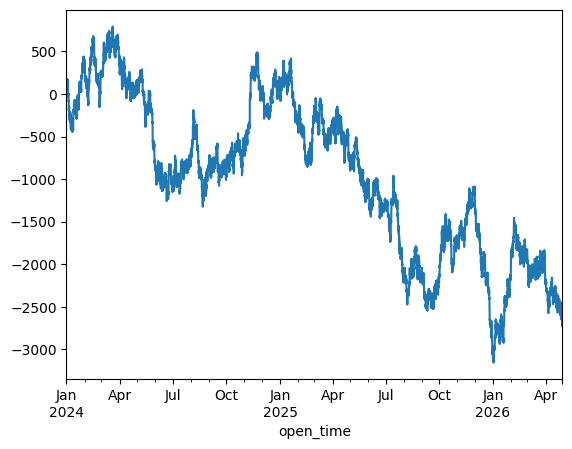

In [6]:
result.pnl.cumsum().plot()